### Load core data/ML libs, plotting tools, and sklearn utilities. We also silence warnings for a cleaner read.

In [2]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.preprocessing import LabelEncoder

# To get diferent metric scores
from sklearn.metrics import (f1_score,accuracy_score,recall_score,precision_score,confusion_matrix,)

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

### Read the Excel file and display the head. 

In [3]:
# Oils dataset
oils_path = r"C:\Users\Admin\Desktop\Raman_Oil data_processed.csv"
df_oils = pd.read_csv(oils_path)
    #.drop(columns=['Unnamed: 0'])

# --- FIX vs original notebook (for consistency with the other fixed notebooks) ---
# This notebook never reversed its spectral columns, and the source file here
# is already ascending by wavenumber, so this step is a no-op on this data -
# it's kept only so column order is explicitly guaranteed (matches
# raman_analysis/data_loading.py::get_spectral_columns in Paper3_code)
# rather than silently relying on the source file's incidental order.
def _is_wavenumber(col):
    try:
        float(col)
        return True
    except ValueError:
        return False

meta_cols = [c for c in df_oils.columns if not _is_wavenumber(c)]
spectral_cols = sorted([c for c in df_oils.columns if _is_wavenumber(c)], key=float)
df_oils = df_oils[meta_cols + spectral_cols]
display(df_oils.head())

,Oil_Type,Oil,500.8563,501.8205,502.7847,503.749,504.7132,505.6774,506.6417,507.6059,...,2990.507,2991.472,2992.436,2993.4,2994.364,2995.329,2996.293,2997.257,2998.221,2999.186
0,SO 0,SO,0.021732,-0.001593,-0.010625,-0.008218,0.002774,0.019496,0.037766,0.056666,...,0.131995,0.185044,0.247140,0.319476,0.401260,0.499017,0.606014,0.720636,0.841272,0.966311
1,SO 0,SO,0.037005,0.027239,0.021703,0.019758,0.020763,0.024080,0.028881,0.034989,...,0.140491,0.188239,0.247283,0.321774,0.408275,0.499878,0.595634,0.693446,0.791217,0.886849
2,SO 0,SO,0.041203,0.008201,-0.004695,-0.002137,0.011217,0.030714,0.048107,0.062211,...,0.155733,0.224433,0.299561,0.375081,0.453001,0.538239,0.632198,0.736531,0.852892,0.982935
3,SO 0,SO,0.026405,0.022237,0.020311,0.020029,0.020791,0.022001,0.022214,0.021510,...,0.124774,0.173861,0.243998,0.327885,0.418259,0.512699,0.614348,0.723232,0.839377,0.962809
4,SO 0,SO,0.028635,0.012872,0.008599,0.012872,0.022751,0.035292,0.044321,0.050085,...,0.161441,0.220895,0.292110,0.366799,0.442062,0.526927,0.619741,0.721437,0.832948,0.955206


This spectrum is already baseline-corrected, smoothed, and normalized using the peak 2720. First the peak maxima of this peak was found for each row and then normalized.

In [116]:
# Spectral data starts from column 2
spectra = df_oils.iloc[:, 2:]

# Most negative value in the entire spectral dataset
min_value = spectra.min().min()

# Find row and column containing the minimum value
row_idx, col_idx = (spectra == min_value).stack().idxmax()

print("Most negative value:", min_value)
print("Most negative value:", min_value)
print("Row index:", row_idx)
print("Wavenumber:", col_idx)
print("Shift skipped (data is already normalized using the peak 2720; negative values are physically meaningful)")
print("Minimum stays:", df_oils.iloc[:, 2:].min().min())

Most negative value: -1.3599112517568004
Most negative value: -1.3599112517568004
Row index: 643
Wavenumber: 2603.901
Shift skipped (data is already normalized using the peak 2720; negative values are physically meaningful)
Minimum stays: -1.3599112517568004


In [ ]:
# Raman shifts
wavenumbers = df_oils.columns[2:].astype(float)

# Regions to keep
mask_left = wavenumbers <= 1900
mask_right = wavenumbers >= 2600

oils = df_oils['Oil'].unique()

fig, axes = plt.subplots(len(oils), 2, figsize=(10, 8), sharey='row', gridspec_kw={"width_ratios":[4,1]})

for idx, oil in enumerate(oils):
    subset = (df_oils[df_oils['Oil'] == oil].iloc[:, 2:].mean(axis=0))
    y = subset.values
    # LEFT SIDE
    axes[idx,0].scatter(wavenumbers[mask_left],y[mask_left],s=2,label=f"Oil type: {oil}")

    # RIGHT SIDE
    axes[idx,1].scatter(wavenumbers[mask_right],y[mask_right],s=2)
    axes[idx,0].set_ylabel("Standardized Intensity (Peak normalized)")
    axes[idx,0].legend(loc="upper right")
    axes[idx,0].grid(alpha=0.3)
    axes[idx,1].grid(alpha=0.3)

    # Remove touching borders
    axes[idx,0].spines['right'].set_visible(False)
    axes[idx,1].spines['left'].set_visible(False)
    axes[idx,1].tick_params(labelleft=False)

    # Broken-axis marks
    d = 0.015
    kwargs = dict(transform=axes[idx,0].transAxes,color='k',clip_on=False)

    axes[idx,0].plot((1-d,1+d),(-d,+d), **kwargs)
    axes[idx,0].plot((1-d,1+d),(1-d,1+d), **kwargs)

    kwargs.update(transform=axes[idx,1].transAxes)

    axes[idx,1].plot((-d,+d),(-d,+d), **kwargs)
    axes[idx,1].plot((-d,+d),(1-d,1+d), **kwargs)

# Labels
axes[-1,0].set_xlabel("Wavenumber (cm$^{-1}$)")
axes[-1,1].set_xlabel("Wavenumber (cm$^{-1}$)")

axes[0,0].set_title("Mean Raman Spectra for Each Oil Type")

plt.tight_layout()
plt.savefig(r"C:\Users\Admin\Downloads\Decision tree_oil_peak normalized data\Raman_spectra_oils_random.jpg",dpi=600,bbox_inches="tight")
plt.show()

**Train/test split.** A single stratified 70/30 split is held out up front and reused for every model below (baseline, pre-pruned, post-pruned), so their test-set numbers are directly comparable to each other. `stratify=y` keeps each oil type's proportion the same in both sets; with a few hundred samples split across 5 classes, a plain random split could otherwise leave a class over- or under-represented in the (already small) test set purely by chance.

In [11]:
### Memory size
df_oils.info(memory_usage = 'deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Columns: 1868 entries, Oil_Type to 2999.186
dtypes: float64(1866), object(2)
memory usage: 14.3 MB


In [12]:
#Define features (X) and Target (y)
X = df_oils.drop(columns=['Oil_Type','Oil'])
y= df_oils['Oil']
X = X.astype(float)

# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1,stratify = y)
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (700, 1866)
Shape of test set :  (300, 1866)
Percentage of classes in training set:
Oil
SO      0.2
SOYO    0.2
GNO     0.2
VO      0.2
PO      0.2
Name: proportion, dtype: float64
Percentage of classes in test set:
Oil
VO      0.2
SO      0.2
GNO     0.2
SOYO    0.2
PO      0.2
Name: proportion, dtype: float64


In [13]:
# Check if X contains any negative values
print("Does X contain negative values?", (X < 0).any().any())

Does X contain negative values? True


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Training features standardized (fit on X_train only).")
print("Training set - max |per-column mean| (should be ~0):", X_train.mean(axis=0).abs().max())
print("Training set - mean per-column std (should be ~1):", X_train.std(axis=0, ddof=0).mean())

Training features standardized (fit on X_train only).
Training set - max |per-column mean| (should be ~0): 4.5017957615657775e-15
Training set - mean per-column std (should be ~1): 1.0


### Define a helper function to compute Accuracy/Recall/Precision/F1 (weighted) for any classifier.

In [15]:
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    # predicting using the independent variables
    pred = model.predict(predictors)
    acc = accuracy_score(target, pred)
    recall = recall_score(target, pred, average="weighted")
    precision = precision_score(target, pred, average="weighted")
    f1 = f1_score(target, pred, average="weighted")

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc,"Recall": recall,"Precision": precision,"F1": f1,},index=[0],)
    return df_perf

### Utility: Confusion matrix to plot a heatmap of the confusion matrix with per-cell percentage annotation.

In [16]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    # 5 oil classes -> a 5x5 confusion matrix
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(5, 5)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Baseline Decision Tree (sklearn defaults): Fit a default tree as a baseline for later comparison.

In [17]:
# No class_weight here (unlike the pre-/post-pruned models below): this
# unconstrained baseline exists purely as an overfitting reference point.
model0 = DecisionTreeClassifier(class_weight="balanced",random_state=1)
model0.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [18]:
le = LabelEncoder()

y_encoded = le.fit_transform(y)

print(le.classes_)

['GNO' 'PO' 'SO' 'SOYO' 'VO']


In [19]:
for i, name in enumerate(le.classes_):
    print(i, "->", name)

0 -> GNO
1 -> PO
2 -> SO
3 -> SOYO
4 -> VO


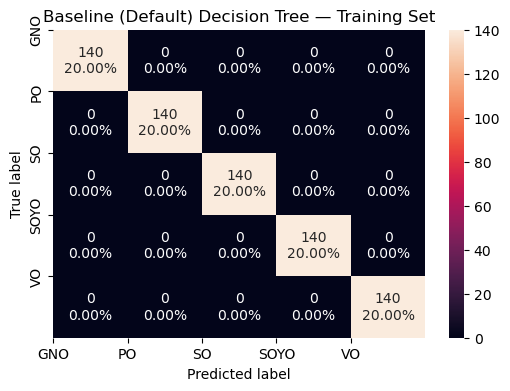

In [21]:
# Draw confusion matrix
confusion_matrix_sklearn(model0, X_train, y_train)

# Get the confusion matrix axes
ax = plt.gca()

# Replace numeric labels with oil names
labels = ['GNO', 'PO', 'SO', 'SOYO', 'VO']

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))

ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

ax.set_title("Baseline (Default) Decision Tree — Training Set")
plt.savefig(r"C:\Users\Admin\Downloads\Decision tree_oil_peak normalized data\default_confusion_matrix_train_oil.jpg",dpi=300,bbox_inches="tight")
plt.show()

In [22]:
decision_tree_default_perf_train = model_performance_classification_sklearn(
    model0, X_train, y_train
)
decision_tree_default_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


In [23]:
# ============================================================
# Hyperparameters used for the Default Decision Tree
# ============================================================

print("=" * 70)
print("DEFAULT DECISION TREE: ALL HYPERPARAMETERS")
print("=" * 70)

default_params = model0.get_params(deep=True)

for param, value in default_params.items():
    print(f"{param}: {value}")

print("=" * 70)
print("Tree characteristics after fitting")
print("=" * 70)

print(f"Tree depth       : {model0.get_depth()}")
print(f"Number of leaves : {model0.get_n_leaves()}")
print(f"Number of nodes  : {model0.tree_.node_count}")

DEFAULT DECISION TREE: ALL HYPERPARAMETERS
ccp_alpha: 0.0
class_weight: balanced
criterion: gini
max_depth: None
max_features: None
max_leaf_nodes: None
min_impurity_decrease: 0.0
min_samples_leaf: 1
min_samples_split: 2
min_weight_fraction_leaf: 0.0
monotonic_cst: None
random_state: 1
splitter: best
Tree characteristics after fitting
Tree depth       : 4
Number of leaves : 6
Number of nodes  : 11


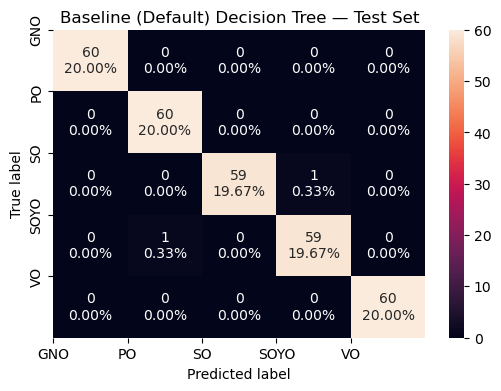

In [25]:
confusion_matrix_sklearn(model0, X_test, y_test)
ax = plt.gca()
labels = ['GNO', 'PO', 'SO', 'SOYO', 'VO']
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_title("Baseline (Default) Decision Tree — Test Set")
plt.savefig(r"C:\Users\Admin\Downloads\Decision tree_oil_peak normalized data\default_confusion_matrix_test_oil.jpg",dpi=300,bbox_inches="tight")
plt.show()

In [26]:
decision_tree_default_perf_test = model_performance_classification_sklearn(
    model0, X_test, y_test
)
decision_tree_default_perf_test

,Accuracy,Recall,Precision,F1
0,0.993333,0.993333,0.993388,0.993333


#### Surprisingly high on test data too with 1,500+ features.

In [27]:
sample_rows = X_test.iloc[:3]
# Predict using model0
pred = model0.predict(sample_rows)

# Show results
for i in range(3):
        print(f"---test case {i+1} ---")
        print("Input Features")
        print(sample_rows.iloc[i])
        print("True Label:", y_test.iloc[i])
        print("Predicted Label:", pred[i])
        print()

---test case 1 ---
Input Features
500.8563    0.140323
501.8205    0.883891
502.7847    1.146790
503.749     1.143465
504.7132    0.992763
              ...   
2995.329   -0.112415
2996.293   -0.336762
2997.257   -0.569769
2998.221   -0.778573
2999.186   -0.921183
Name: 884, Length: 1866, dtype: float64
True Label: VO
Predicted Label: VO

---test case 2 ---
Input Features
500.8563   -0.108965
501.8205    0.101157
502.7847    0.300946
503.749     0.465638
504.7132    0.602862
              ...   
2995.329    0.860535
2996.293    1.042499
2997.257    1.222157
2998.221    1.388685
2999.186    1.504667
Name: 96, Length: 1866, dtype: float64
True Label: SO
Predicted Label: SO

---test case 3 ---
Input Features
500.8563   -0.651585
501.8205   -0.659304
502.7847   -0.635278
503.749    -0.720372
504.7132   -0.870787
              ...   
2995.329    0.034976
2996.293    0.071848
2997.257    0.102679
2998.221    0.124987
2999.186    0.134589
Name: 403, Length: 1866, dtype: float64
True Label: GN

### Prepruning

### Pre‑pruning: small grid search: Search over `max_depth`, `max_leaf_nodes`, `min_samples_split`; keep the model with the **best test recall** and smallest train–test gap.

**Pre-pruning hyperparameters.** `max_depth` caps how many splits deep the tree can grow, `max_leaf_nodes` caps the total number of terminal nodes, and `min_samples_split` requires a node to hold at least that many training samples before it is allowed to split further - all three restrict tree growth *during* fitting, as opposed to the cost-complexity post-pruning further below, which grows a full tree first and prunes it back afterward. `class_weight="balanced"` reweights each training sample by `n_samples / (n_classes * n_samples_of_its_class)`, so a rarer class counts for more in the split criterion; it is applied here (and in post-pruning) for robustness to any class imbalance the train/test split introduces. Hyperparameters are chosen by 5-fold cross-validated weighted recall on the training set only - the test set is not touched until the winning model is evaluated once, at the end.

In [28]:
# Define the parameters of the tree to iterate over
max_depth_values = np.arange(2, 7, 2)
max_leaf_nodes_values = [50, 75, 150, 250]
min_samples_split_values = [10, 30, 50, 70]
cv = 5
verbose = 1
param_grid = {
"max_depth": list(max_depth_values),
"max_leaf_nodes": list(max_leaf_nodes_values),
"min_samples_split": list(min_samples_split_values),
}
search = GridSearchCV(
DecisionTreeClassifier(class_weight="balanced", random_state=1),
param_grid=param_grid,
scoring="recall_weighted",cv= StratifiedKFold(n_splits=cv, shuffle=True, random_state= 1),refit=True,
verbose=verbose)
search.fit(X_train, y_train)

columns = ["params", "mean_test_score", "std_test_score", "rank_test_score"]
cv_results = (pd.DataFrame(search.cv_results_)[columns].sort_values("rank_test_score").reset_index(drop=True)
)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


In [29]:
cv_results.head()

,params,mean_test_score,std_test_score,rank_test_score
0,"{'max_depth': 4, 'max_leaf_nodes': 75, 'min_sa...",0.997143,0.003499,1
1,"{'max_depth': 4, 'max_leaf_nodes': 150, 'min_s...",0.997143,0.003499,1
2,"{'max_depth': 4, 'max_leaf_nodes': 150, 'min_s...",0.997143,0.003499,1
3,"{'max_depth': 4, 'max_leaf_nodes': 250, 'min_s...",0.997143,0.003499,1
4,"{'max_depth': 4, 'max_leaf_nodes': 250, 'min_s...",0.997143,0.003499,1


In [30]:
search.best_estimator_

,criterion,'gini'
,splitter,'best'
,max_depth,np.int64(4)
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,50
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [31]:
# creating an instance of the best model
model1 = search.best_estimator_

# fitting the best model to the training data
pred = model1.predict(X_train)

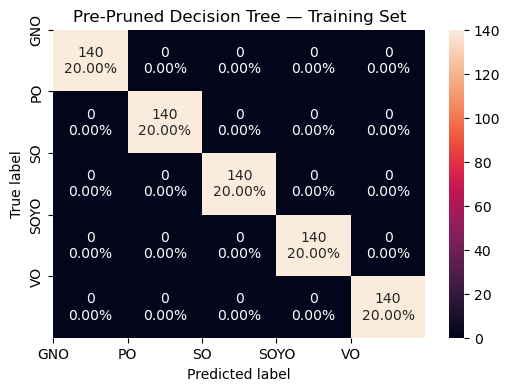

In [33]:
confusion_matrix_sklearn(model1, X_train, y_train)
ax = plt.gca()
labels = ['GNO', 'PO', 'SO', 'SOYO', 'VO']
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_title("Pre-Pruned Decision Tree — Training Set")
plt.savefig(r"C:\Users\Admin\Downloads\Decision tree_oil_peak normalized data\confusion_matrix_train_prepruned_oil.jpg",dpi=300,bbox_inches="tight")
plt.show()

### Visualize the pre‑pruned tree: Plot the structure—useful to see which features split early.

In [34]:
decision_tree_tune_perf_train = model_performance_classification_sklearn(model1, X_train, y_train)
decision_tree_tune_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


In [35]:
# ============================================================
# Hyperparameters used for the Pre-Pruned Decision Tree
# ============================================================

print("=" * 70)
print("PRE-PRUNED DECISION TREE: ALL HYPERPARAMETERS")
print("=" * 70)

prepruned_params = model1.get_params(deep=True)

for param, value in prepruned_params.items():
    print(f"{param}: {value}")

print("=" * 70)
print("BEST PARAMETERS SELECTED BY GRID SEARCH")
print("=" * 70)

for param, value in search.best_params_.items():
    print(f"{param}: {value}")

print("=" * 70)
print("BEST CROSS-VALIDATION SCORE")
print("=" * 70)

print(f"Best weighted recall: {search.best_score_:.6f}")

print("=" * 70)
print("Tree characteristics after fitting")
print("=" * 70)

print(f"Tree depth       : {model1.get_depth()}")
print(f"Number of leaves : {model1.get_n_leaves()}")
print(f"Number of nodes  : {model1.tree_.node_count}")

PRE-PRUNED DECISION TREE: ALL HYPERPARAMETERS
ccp_alpha: 0.0
class_weight: balanced
criterion: gini
max_depth: 4
max_features: None
max_leaf_nodes: 50
min_impurity_decrease: 0.0
min_samples_leaf: 1
min_samples_split: 10
min_weight_fraction_leaf: 0.0
monotonic_cst: None
random_state: 1
splitter: best
BEST PARAMETERS SELECTED BY GRID SEARCH
max_depth: 4
max_leaf_nodes: 50
min_samples_split: 10
BEST CROSS-VALIDATION SCORE
Best weighted recall: 0.997143
Tree characteristics after fitting
Tree depth       : 4
Number of leaves : 6
Number of nodes  : 11


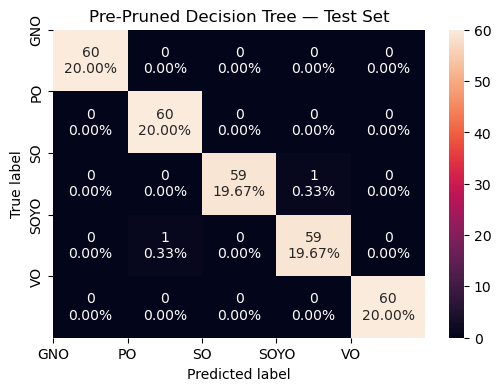

In [37]:
confusion_matrix_sklearn(model1, X_test, y_test)
ax = plt.gca()
labels = ['GNO', 'PO', 'SO', 'SOYO', 'VO']
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_title("Pre-Pruned Decision Tree — Test Set")
plt.savefig(r"C:\Users\Admin\Downloads\Decision tree_oil_peak normalized data\confusion_matrix_test_prepruned_oil.jpg",dpi=300,bbox_inches="tight")
plt.show()

In [38]:
decision_tree_tune_perf_test = model_performance_classification_sklearn(
    model1, X_test, y_test
)
decision_tree_tune_perf_test

,Accuracy,Recall,Precision,F1
0,0.993333,0.993333,0.993388,0.993333


### Save indices/importances for later reuse

In [39]:
feature_names = list(X_train.columns)
importances = model1.feature_importances_
indices = np.argsort(importances)

### Plot the tree

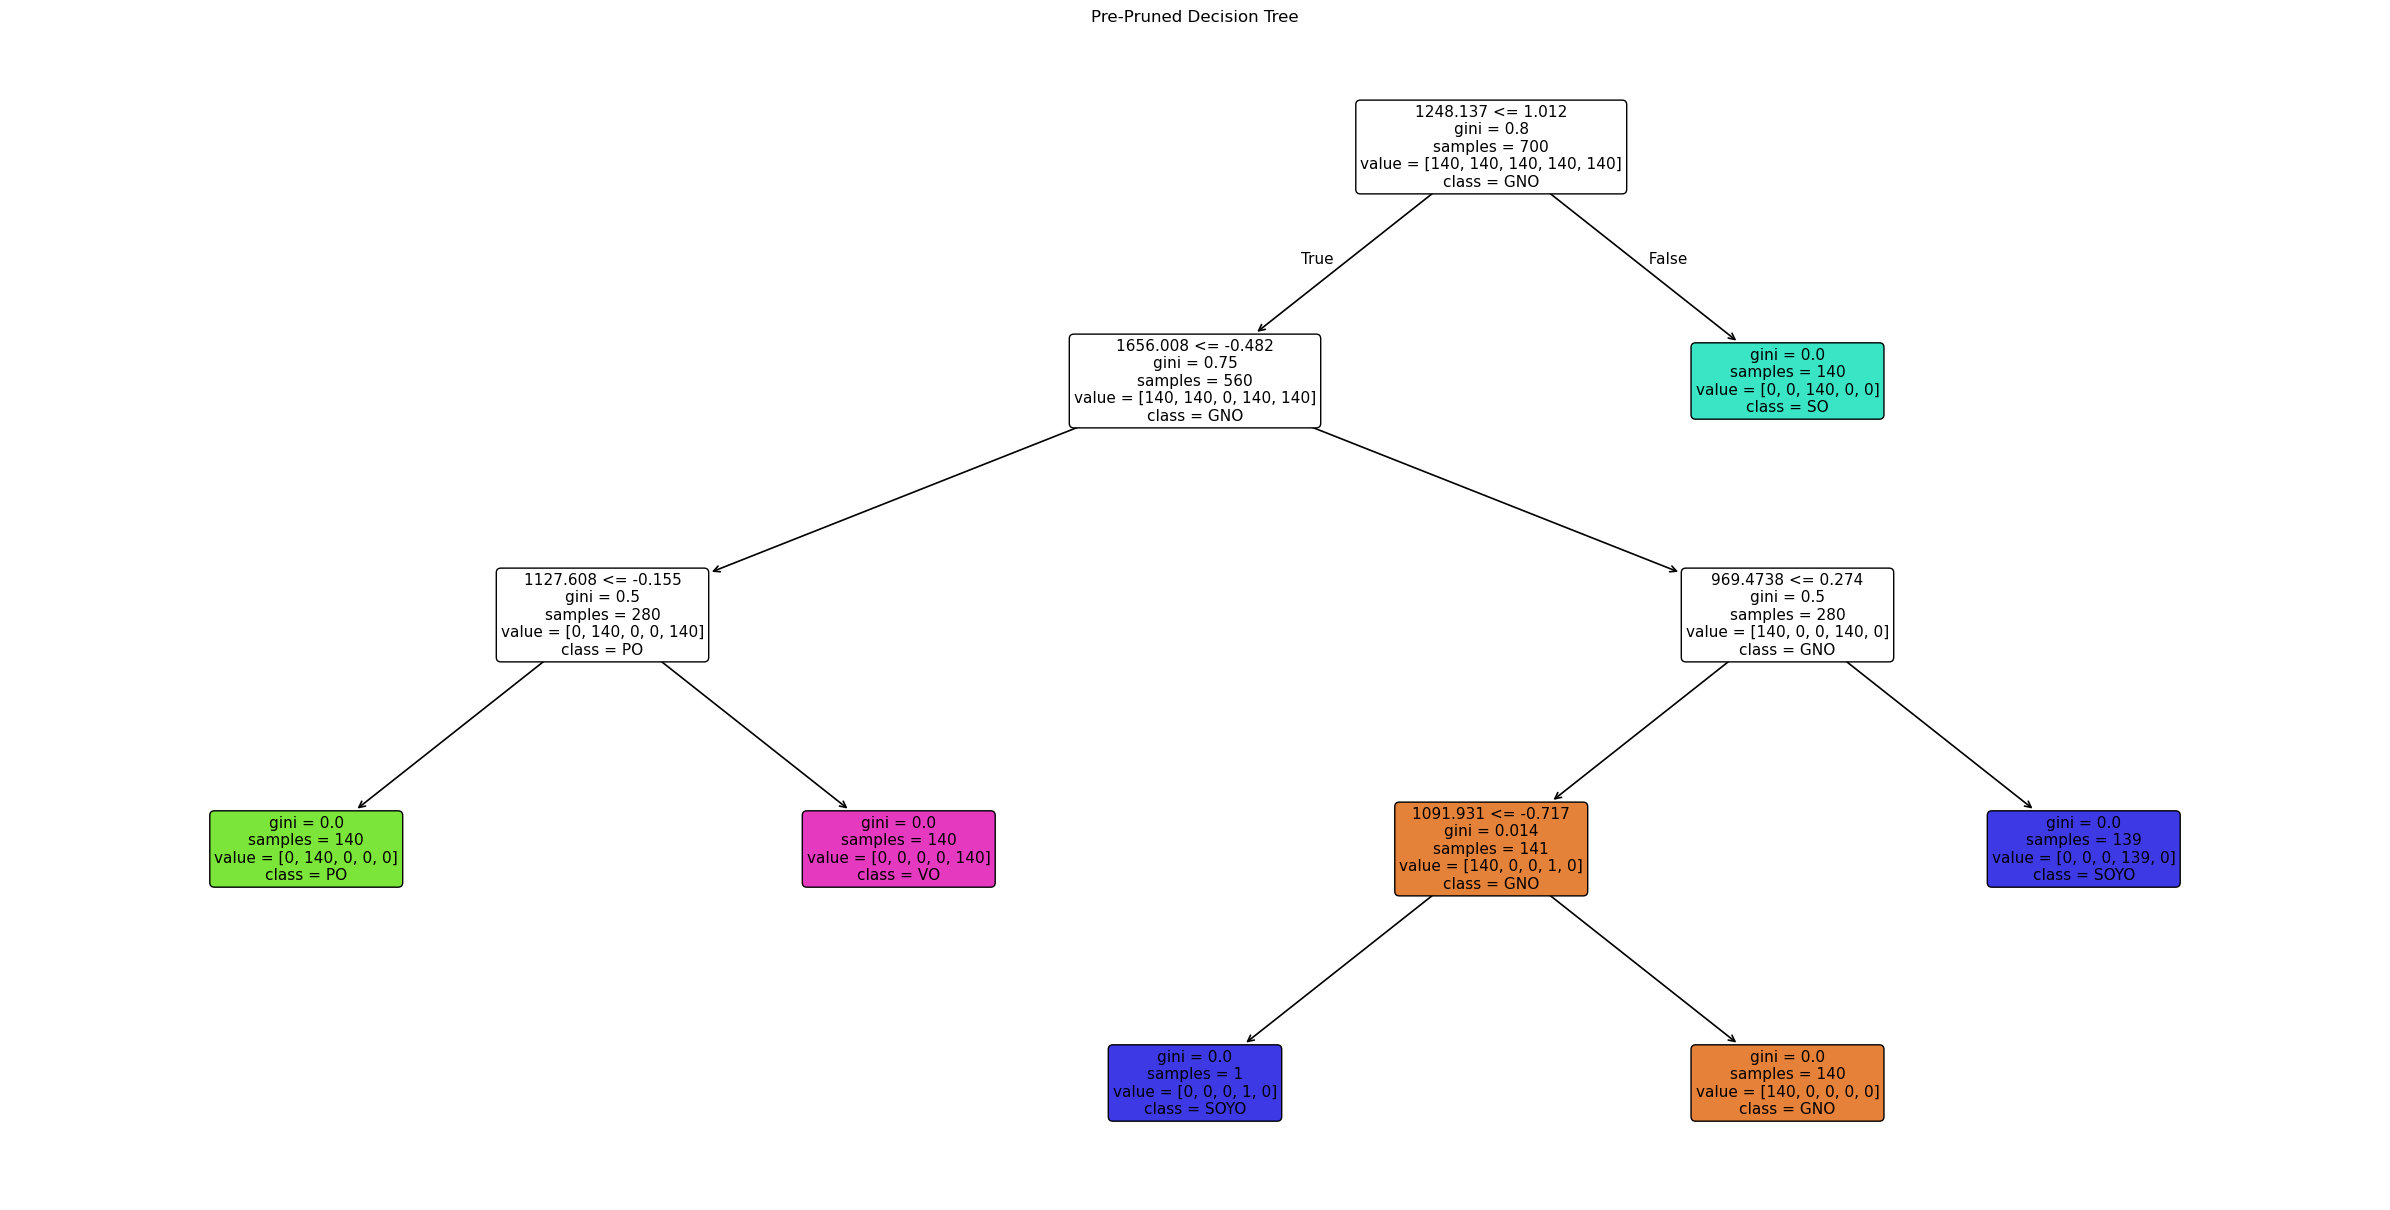

In [41]:
class_names = ['GNO', 'PO', 'SO', 'SOYO', 'VO']

plt.figure(figsize=(24, 12))

out = tree.plot_tree(
    model1,
    feature_names=feature_names,
    class_names=class_names,   # <-- adds class names
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,          # <-- keeps actual counts
    fontsize=11,
    node_ids=False
)

for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1.2)

plt.tight_layout()

plt.title("Pre-Pruned Decision Tree")
plt.savefig(r"C:\Users\Admin\Downloads\Decision tree_oil_peak normalized data\Prepruned_Decision_Tree_oils.jpg",dpi=600,bbox_inches="tight")
plt.show()

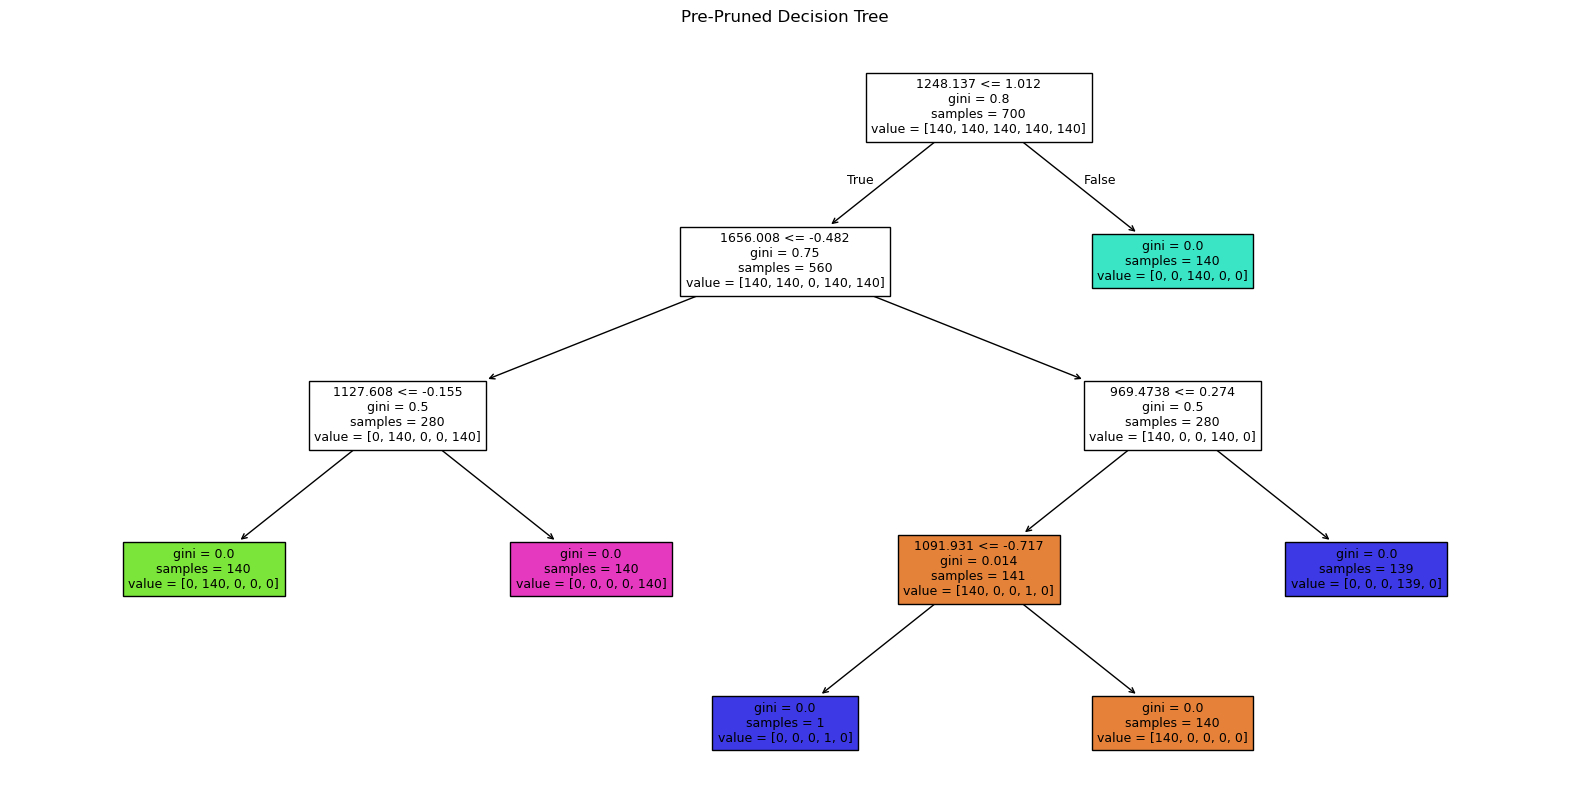

In [42]:
plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    model1,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.title("Pre-Pruned Decision Tree")
plt.show()

In [43]:
for i, name in enumerate(le.classes_):
    print(f"{i}: {name}")

0: GNO
1: PO
2: SO
3: SOYO
4: VO


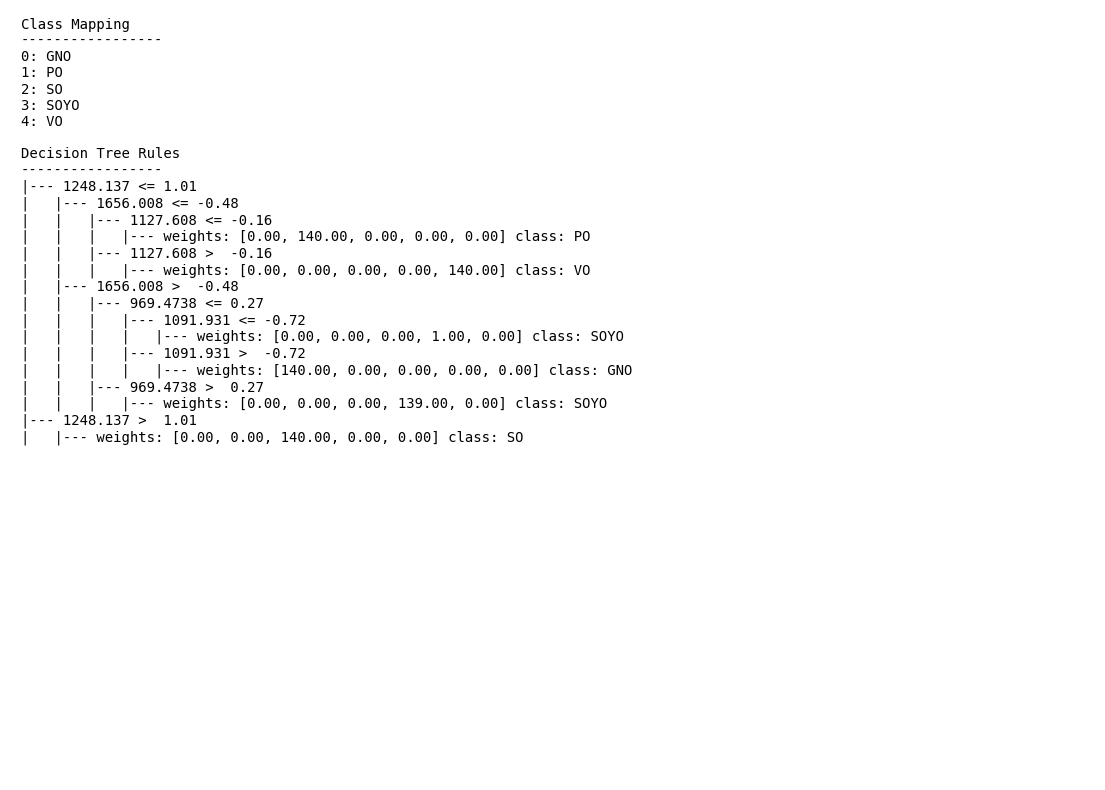

In [45]:
# Create text report
report = tree.export_text(
    model1,
    feature_names=feature_names,
    show_weights=True
)

# Add class mapping at top
mapping_text = "\n".join(
    [f"{i}: {name}" for i, name in enumerate(le.classes_)]
)

full_report = (
    "Class Mapping\n"
    "-----------------\n"
    f"{mapping_text}\n\n"
    "Decision Tree Rules\n"
    "-----------------\n"
    f"{report}"
)

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))
ax.axis("off")

ax.text(
    0.01,
    0.99,
    full_report,
    family="monospace",
    fontsize=10,
    va="top"
)

plt.savefig(r"C:\Users\Admin\Downloads\Decision tree_oil_peak normalized data\Prepruned_Decision_Tree_Text_Report_Oils.jpg",dpi=600,bbox_inches="tight")
plt.show()

In [46]:
# Text report showing the rules of a decision tree -
print(tree.export_text(model1, feature_names=feature_names, show_weights=True))

|--- 1248.137 <= 1.01
|   |--- 1656.008 <= -0.48
|   |   |--- 1127.608 <= -0.16
|   |   |   |--- weights: [0.00, 140.00, 0.00, 0.00, 0.00] class: PO
|   |   |--- 1127.608 >  -0.16
|   |   |   |--- weights: [0.00, 0.00, 0.00, 0.00, 140.00] class: VO
|   |--- 1656.008 >  -0.48
|   |   |--- 969.4738 <= 0.27
|   |   |   |--- 1091.931 <= -0.72
|   |   |   |   |--- weights: [0.00, 0.00, 0.00, 1.00, 0.00] class: SOYO
|   |   |   |--- 1091.931 >  -0.72
|   |   |   |   |--- weights: [140.00, 0.00, 0.00, 0.00, 0.00] class: GNO
|   |   |--- 969.4738 >  0.27
|   |   |   |--- weights: [0.00, 0.00, 0.00, 139.00, 0.00] class: SOYO
|--- 1248.137 >  1.01
|   |--- weights: [0.00, 0.00, 140.00, 0.00, 0.00] class: SO



In [47]:
importances = model1.feature_importances_
importances

array([0., 0., 0., ..., 0., 0., 0.], shape=(1866,))

In [48]:
print(np.sum(importances > 0))

5


**Reading feature importance.** scikit-learn's Gini importance for a wavenumber sums the (sample-weighted) impurity decrease at every split in the tree that used it, then normalizes so all importances sum to 1. It reflects how much a wavenumber helped separate classes *within this specific tree*, not a model-free measure of how discriminative that Raman band is in isolation: because neighboring wavenumbers are highly correlated, the tree only needs to pick one of several near-equivalent candidates at a split, so an unused neighbor can be just as chemically informative as a used one that scores higher here. Only wavenumbers actually used by a split get a nonzero score, which is why the plot below only shows that nonzero subset.

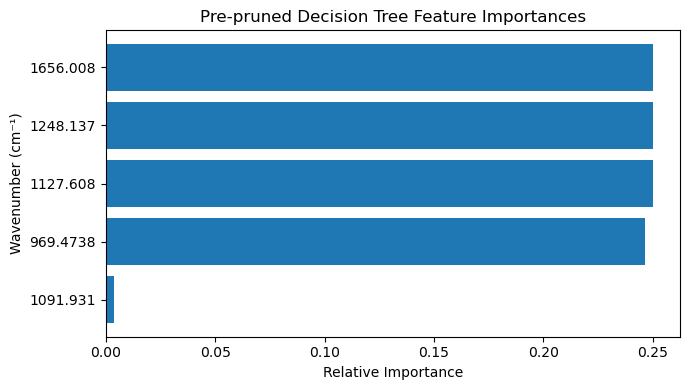

In [50]:
importances = model1.feature_importances_

# Keep only features used by the tree
mask = importances > 0

important_features = np.array(feature_names)[mask]
important_values = importances[mask]

# Sort by importance
idx = np.argsort(important_values)

plt.figure(figsize=(7,4))

plt.barh(
    range(len(idx)),
    important_values[idx]
)

plt.yticks(
    range(len(idx)),
    important_features[idx]
)

plt.xlabel("Relative Importance")
plt.ylabel("Wavenumber (cm⁻¹)")
plt.title("Pre-pruned Decision Tree Feature Importances")

plt.tight_layout()

plt.savefig(r"C:\Users\Admin\Downloads\Decision tree_oil_peak normalized data\decision_tree_feature_importance_oils.jpg",dpi=600,bbox_inches="tight")
plt.show()

In [51]:
for f, imp in zip(feature_names, importances):
    if imp > 0:
        print(f"{f} : {imp:.4f}")

969.4738 : 0.2465
1091.931 : 0.0035
1127.608 : 0.2500
1248.137 : 0.2500
1656.008 : 0.2500


In [52]:
df_oils.head()

,Oil_Type,Oil,500.8563,501.8205,502.7847,503.749,504.7132,505.6774,506.6417,507.6059,...,2990.507,2991.472,2992.436,2993.4,2994.364,2995.329,2996.293,2997.257,2998.221,2999.186
0,SO 0,SO,0.021732,-0.001593,-0.010625,-0.008218,0.002774,0.019496,0.037766,0.056666,...,0.131995,0.185044,0.247140,0.319476,0.401260,0.499017,0.606014,0.720636,0.841272,0.966311
1,SO 0,SO,0.037005,0.027239,0.021703,0.019758,0.020763,0.024080,0.028881,0.034989,...,0.140491,0.188239,0.247283,0.321774,0.408275,0.499878,0.595634,0.693446,0.791217,0.886849
2,SO 0,SO,0.041203,0.008201,-0.004695,-0.002137,0.011217,0.030714,0.048107,0.062211,...,0.155733,0.224433,0.299561,0.375081,0.453001,0.538239,0.632198,0.736531,0.852892,0.982935
3,SO 0,SO,0.026405,0.022237,0.020311,0.020029,0.020791,0.022001,0.022214,0.021510,...,0.124774,0.173861,0.243998,0.327885,0.418259,0.512699,0.614348,0.723232,0.839377,0.962809
4,SO 0,SO,0.028635,0.012872,0.008599,0.012872,0.022751,0.035292,0.044321,0.050085,...,0.161441,0.220895,0.292110,0.366799,0.442062,0.526927,0.619741,0.721437,0.832948,0.955206


In [53]:
# Get wavenumbers/features used by the decision tree
important_features = [
    f for f, imp in zip(feature_names, importances)
    if imp > 0
]

# Keep the 'Oil' column + important wavenumbers
df_features = df_oils[['Oil'] + important_features].copy()

# Check the result
df_features.head()

,Oil,969.4738,1091.931,1127.608,1248.137,1656.008
0,SO,0.728209,0.676830,0.027496,1.095470,4.366887
1,SO,0.709701,0.659221,0.004989,1.108856,4.213464
2,SO,0.721083,0.700240,0.020264,1.106329,4.333619
3,SO,0.708035,0.677376,-0.009334,1.138133,4.170835
4,SO,0.711186,0.656688,0.003493,1.108061,4.179599


In [55]:
df_features.to_csv(r"C:\Users\Admin\Downloads\Decision tree_oil_peak normalized data\df_features.csv", index=False)

In [56]:
df_features.info(memory_usage = 'deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Oil       1000 non-null   object 
 1   969.4738  1000 non-null   float64
 2   1091.931  1000 non-null   float64
 3   1127.608  1000 non-null   float64
 4   1248.137  1000 non-null   float64
 5   1656.008  1000 non-null   float64
dtypes: float64(5), object(1)
memory usage: 89.6 KB


In [71]:
# ---------------------------------------------------------
# Test classification using ONLY the 5 DT-selected wavenumbers
# ---------------------------------------------------------

# The 5 wavenumbers selected by the pre-pruned decision tree
selected_wavenumbers = ['969.4738','1091.931','1127.608','1248.137','1656.008']

# X = only the 5 selected wavenumbers
X_5 = df_features[selected_wavenumbers].astype(float)

# Target
y_5 = df_features['Oil']

# Same train/test split used in the original notebook
X_train_5, X_test_5, y_train_5, y_test_5 = train_test_split(
    X_5,
    y_5,
    test_size=0.30,
    random_state=1,
    stratify=y_5
)

**Same column-wise policy as above, fit independently here.** This retrains on a different feature subset (just these 5 tree-selected wavenumbers) than the full-feature model, so it needs its own scaler fit on its own training split - reusing the full-feature scaler would mix in statistics from features that aren't even used here. As above, this is a units/consistency choice: restricting to 5 already-selected wavenumbers and re-fitting a Decision Tree on them is unaffected by their scale.

In [72]:
scaler_5 = StandardScaler()
X_train_5 = pd.DataFrame(scaler_5.fit_transform(X_train_5), columns=X_train_5.columns, index=X_train_5.index)
X_test_5 = pd.DataFrame(scaler_5.transform(X_test_5), columns=X_test_5.columns, index=X_test_5.index)

In [73]:
# Build the decision tree using ONLY these 5 wavenumbers
model_5 = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=5,
    max_leaf_nodes=50,
    min_samples_split=10,
    random_state=1
)

# Fit
model_5.fit(X_train_5, y_train_5)

# Predictions
y_train_pred_5 = model_5.predict(X_train_5)
y_test_pred_5 = model_5.predict(X_test_5)

# ---------------------------------------------------------
# Performance
# ---------------------------------------------------------

train_accuracy_5 = accuracy_score(y_train_5, y_train_pred_5)
test_accuracy_5 = accuracy_score(y_test_5, y_test_pred_5)

train_recall_5 = recall_score(y_train_5, y_train_pred_5, average='weighted')
test_recall_5 = recall_score(y_test_5, y_test_pred_5, average='weighted')

train_precision_5 = precision_score(y_train_5, y_train_pred_5, average='weighted')
test_precision_5 = precision_score(y_test_5, y_test_pred_5, average='weighted')

train_f1_5 = f1_score(y_train_5, y_train_pred_5, average='weighted')
test_f1_5 = f1_score(y_test_5, y_test_pred_5, average='weighted')

print("Using ONLY these 5 wavenumbers:")
print(selected_wavenumbers)

print("\nTraining Performance")
print("--------------------")
print(f"Accuracy  : {train_accuracy_5:.5f}")
print(f"Recall    : {train_recall_5:.5f}")
print(f"Precision : {train_precision_5:.5f}")
print(f"F1 Score  : {train_f1_5:.5f}")

print("\nTest Performance")
print("----------------")
print(f"Accuracy  : {test_accuracy_5:.5f}")
print(f"Recall    : {test_recall_5:.5f}")
print(f"Precision : {test_precision_5:.5f}")
print(f"F1 Score  : {test_f1_5:.5f}")

Using ONLY these 5 wavenumbers:
['969.4738', '1091.931', '1127.608', '1248.137', '1656.008']

Training Performance
--------------------
Accuracy  : 1.00000
Recall    : 1.00000
Precision : 1.00000
F1 Score  : 1.00000

Test Performance
----------------
Accuracy  : 0.99000
Recall    : 0.99000
Precision : 0.99016
F1 Score  : 0.99003


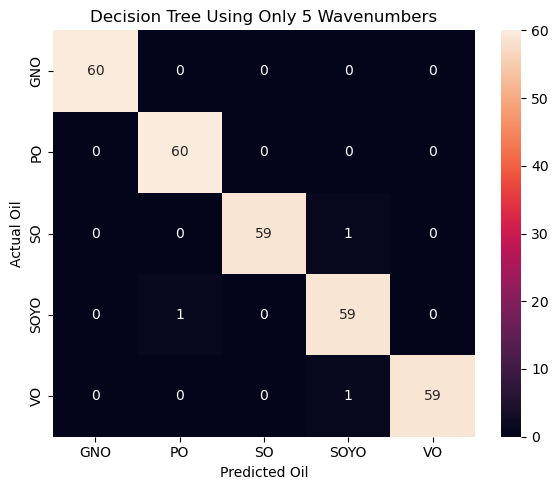

In [74]:
# Confusion matrix for the 5-wavenumber model

cm_5 = confusion_matrix(y_test_5, y_test_pred_5)

labels = sorted(y_5.unique())

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_5,
    annot=True,
    fmt='d',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Oil")
plt.ylabel("Actual Oil")
plt.title("Decision Tree Using Only 5 Wavenumbers")

plt.tight_layout()

plt.savefig(
    r"C:\Users\Admin\Downloads\Decision tree_oil_peak normalized data\confusion_matrix_test_5_wavenumbers_oils.jpg",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [75]:
# Verify 100% correct classification
results_5 = pd.DataFrame({
    'Actual': y_test_5.values,
    'Predicted': y_test_pred_5
})

results_5['Correct'] = results_5['Actual'] == results_5['Predicted']

print(results_5['Correct'].value_counts())

print("\nNumber of incorrect predictions:",
      (~results_5['Correct']).sum())

print("Test samples:",
      len(results_5))

print("Test accuracy:",
      results_5['Correct'].mean())

Correct
True     297
False      3
Name: count, dtype: int64

Number of incorrect predictions: 3
Test samples: 300
Test accuracy: 0.99


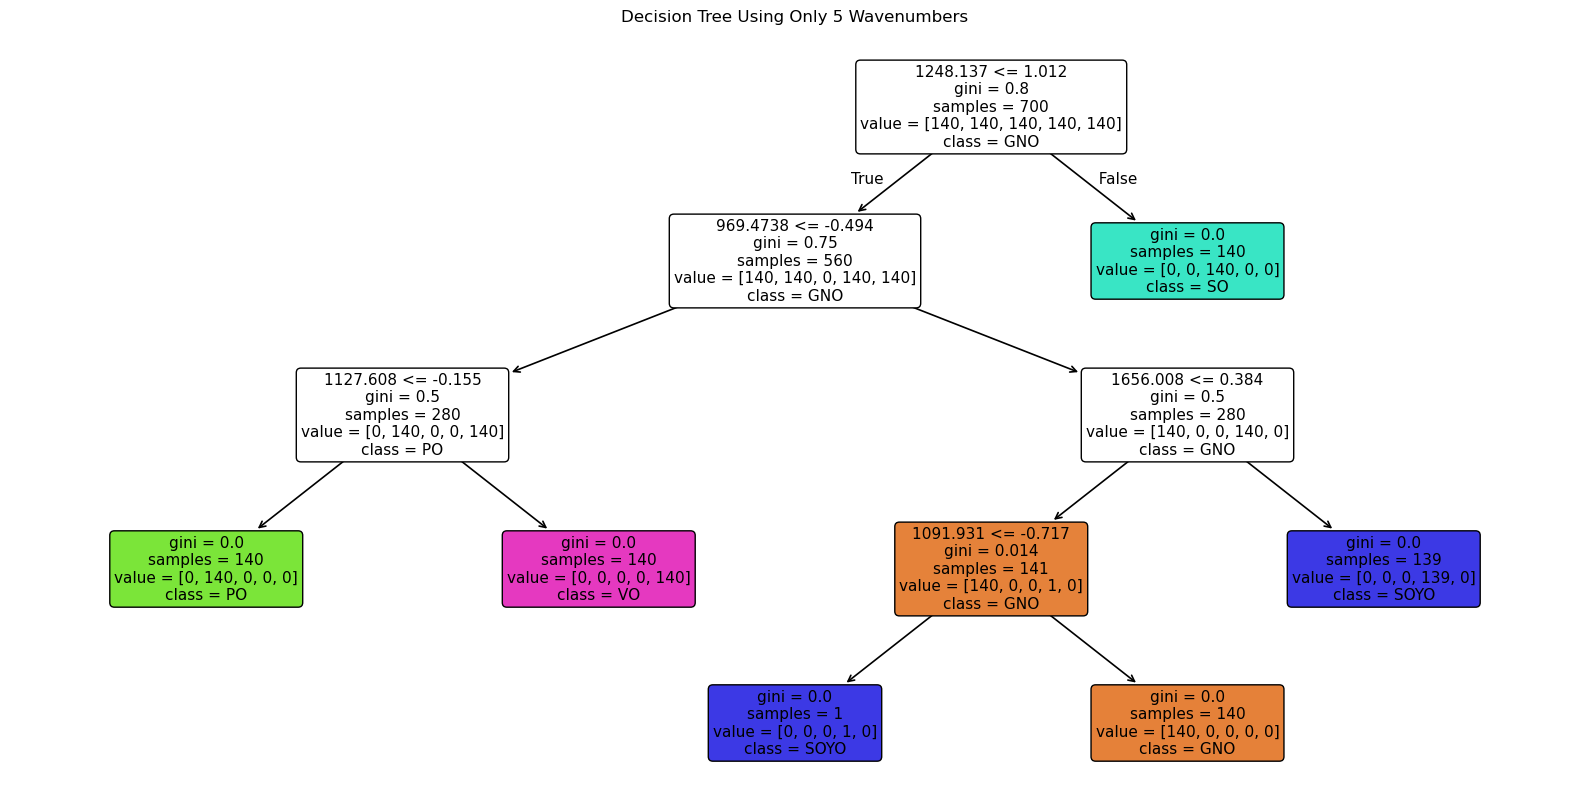

In [76]:
class_names_5 = list(model_5.classes_)

plt.figure(figsize=(16, 8))

out = tree.plot_tree(
    model_5,
    feature_names=selected_wavenumbers,
    class_names=class_names_5,
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    fontsize=11,
    node_ids=False
)

for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1.2)

plt.tight_layout()

plt.title("Decision Tree Using Only 5 Wavenumbers")
plt.savefig(r"C:\Users\Admin\Downloads\Decision tree_oil_peak normalized data\FourFeature_Decision_Tree_oils.jpg", dpi=600, bbox_inches="tight")
plt.show()

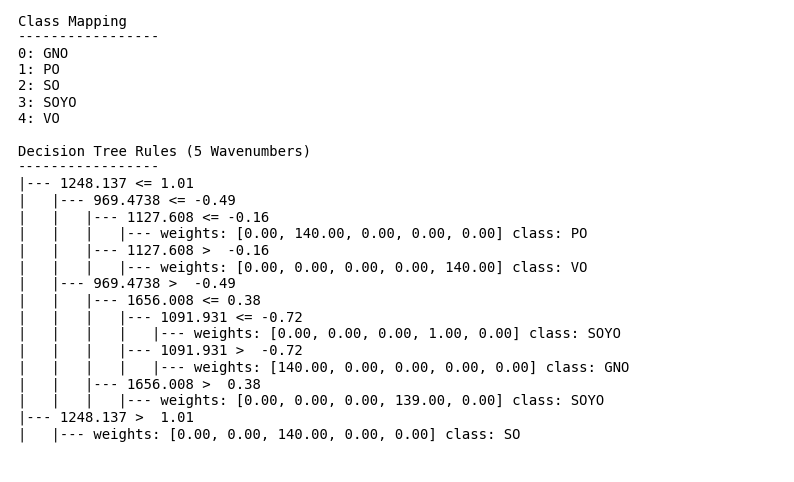

In [78]:
# Create text report
report_5 = tree.export_text(
    model_5,
    feature_names=selected_wavenumbers,
    show_weights=True
)

# Add class mapping at top
mapping_text_5 = "\n".join(
    [f"{i}: {name}" for i, name in enumerate(model_5.classes_)]
)

full_report_5 = (
    "Class Mapping\n"
    "-----------------\n"
    f"{mapping_text_5}\n\n"
    "Decision Tree Rules (5 Wavenumbers)\n"
    "-----------------\n"
    f"{report_5}"
)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis("off")

ax.text(
    0.01,
    0.99,
    full_report_5,
    family="monospace",
    fontsize=10,
    va="top"
)

plt.savefig(r"C:\Users\Admin\Downloads\Decision tree_oil_peak normalized data\FourFeature_Decision_Tree_Text_Report_Oils.jpg", dpi=600, bbox_inches="tight")
plt.show()

### Post-pruning

### Post‑pruning via Cost‑Complexity Path: Compute `ccp_alphas` and impurities to study pruning trajectory.

For a fully grown tree *T*, cost-complexity pruning defines

R_α(T) = R(T) + α·|leaves(T)|

where R(T) is T's total training impurity and |leaves(T)| its number of leaves. α trades fit against size: α = 0 is the fully grown tree, and increasing α makes larger subtrees costlier, until at each of a finite sequence of α values the optimal subtree collapses its weakest-link node. `cost_complexity_pruning_path` returns exactly that sequence of α values and each one's corresponding leaf impurity.

In [79]:
clf = DecisionTreeClassifier(random_state=1, class_weight="balanced")
path = clf.cost_complexity_pruning_path(X_train, y_train)
# sklearn's ccp_alphas are already >= 0 in practice; abs() guards against a
# stray floating-point sign flip on a value that should be exactly 0.
ccp_alphas, impurities = abs(path.ccp_alphas), path.impurities

In [80]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000,0.000000
1,0.002837,0.002837
2,0.197163,0.200000
3,0.200000,0.600000
4,0.200000,0.800000


### Impurity vs α (training) from the above summary: Heavier pruning (larger α) reduces tree size and increases leaf impurity.


In [81]:
print(model1.get_n_leaves())
print(model1.get_depth())

6
4


In [82]:
alphas = path.ccp_alphas

for alpha in alphas:
    # class_weight="balanced" to match the tree sequence built below and
    # the final selected model - this loop is a depth/leaf diagnostic
    # only (its trees are never kept), but should still describe the
    # same tree the rest of this stage actually uses.
    clf = DecisionTreeClassifier(random_state=1, ccp_alpha=alpha, class_weight="balanced")
    clf.fit(X_train, y_train)

    print(
        f"alpha={alpha:.6f}",
        "depth=", clf.get_depth(),
        "leaves=", clf.get_n_leaves()
    )

alpha=0.000000 depth= 4 leaves= 6
alpha=0.002837 depth= 3 leaves= 5
alpha=0.197163 depth= 3 leaves= 4
alpha=0.200000 depth= 1 leaves= 2
alpha=0.200000 depth= 0 leaves= 1


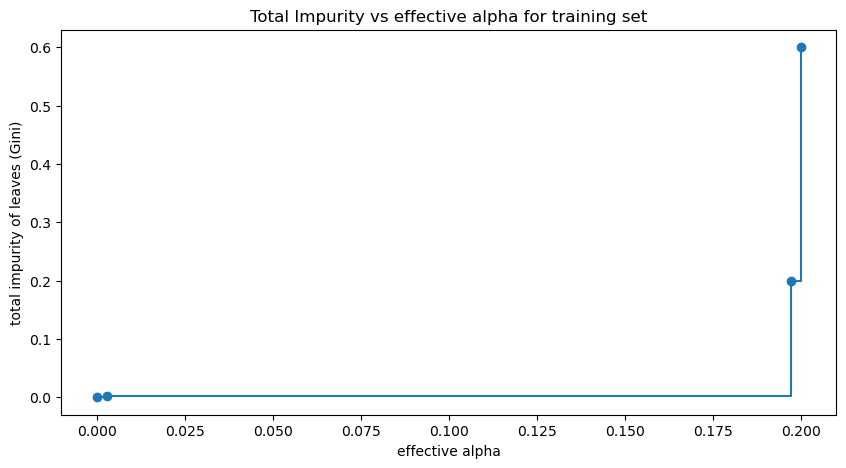

In [83]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves (Gini)")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

### Fit trees across α values: Train a sequence of pruned trees; we’ll compare metrics across α.


In [84]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=1, ccp_alpha=ccp_alpha, class_weight="balanced")
    clf.fit(X_train, y_train)
    clfs.append(clf)
print("Number of nodes in the last tree is: {} with ccp_alpha: {}".format(clfs[-1].tree_.node_count, ccp_alphas[-1]))

Number of nodes in the last tree is: 1 with ccp_alpha: 0.20000000000000007


In [85]:
param_grid = {"ccp_alpha": list(ccp_alphas)}
search = GridSearchCV(DecisionTreeClassifier(random_state=1, class_weight='balanced'),param_grid=param_grid,
scoring="recall_weighted",cv=StratifiedKFold(n_splits= 5, shuffle=True, random_state=1),refit=True,
verbose= 1)
search.fit(X_train, y_train)

cv_table = pd.DataFrame({
"ccp_alpha": param_grid["ccp_alpha"],
"mean_cv_recall": search.cv_results_["mean_test_score"],
"std_cv_recall": search.cv_results_["std_test_score"],
}).sort_values("ccp_alpha").reset_index(drop=True)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


In [86]:
model2 = search.best_estimator_
cv_table.head()

,ccp_alpha,mean_cv_recall,std_cv_recall
0,0.000000,0.997143,0.003499
1,0.002837,0.997143,0.003499
2,0.197163,0.838571,0.077143
3,0.200000,0.838571,0.077143
4,0.200000,0.200000,0.000000


In [87]:
# ============================================================
# Hyperparameters used for the Post-Pruned Decision Tree
# ============================================================

print("=" * 70)
print("POST-PRUNED DECISION TREE: ALL HYPERPARAMETERS")
print("=" * 70)

postpruned_params = model2.get_params(deep=True)

for param, value in postpruned_params.items():
    print(f"{param}: {value}")

print("=" * 70)
print("BEST POST-PRUNING PARAMETER SELECTED BY GRID SEARCH")
print("=" * 70)

for param, value in search.best_params_.items():
    print(f"{param}: {value}")

print("=" * 70)
print("BEST CROSS-VALIDATION SCORE")
print("=" * 70)

print(f"Best weighted recall: {search.best_score_:.6f}")

print("=" * 70)
print("Tree characteristics after fitting")
print("=" * 70)

print(f"Tree depth       : {model2.get_depth()}")
print(f"Number of leaves : {model2.get_n_leaves()}")
print(f"Number of nodes  : {model2.tree_.node_count}")

POST-PRUNED DECISION TREE: ALL HYPERPARAMETERS
ccp_alpha: 0.0
class_weight: balanced
criterion: gini
max_depth: None
max_features: None
max_leaf_nodes: None
min_impurity_decrease: 0.0
min_samples_leaf: 1
min_samples_split: 2
min_weight_fraction_leaf: 0.0
monotonic_cst: None
random_state: 1
splitter: best
BEST POST-PRUNING PARAMETER SELECTED BY GRID SEARCH
ccp_alpha: 0.0
BEST CROSS-VALIDATION SCORE
Best weighted recall: 0.997143
Tree characteristics after fitting
Tree depth       : 4
Number of leaves : 6
Number of nodes  : 11


### Node count / Depth vs α: Sanity‑check that pruning controls complexity as expected.

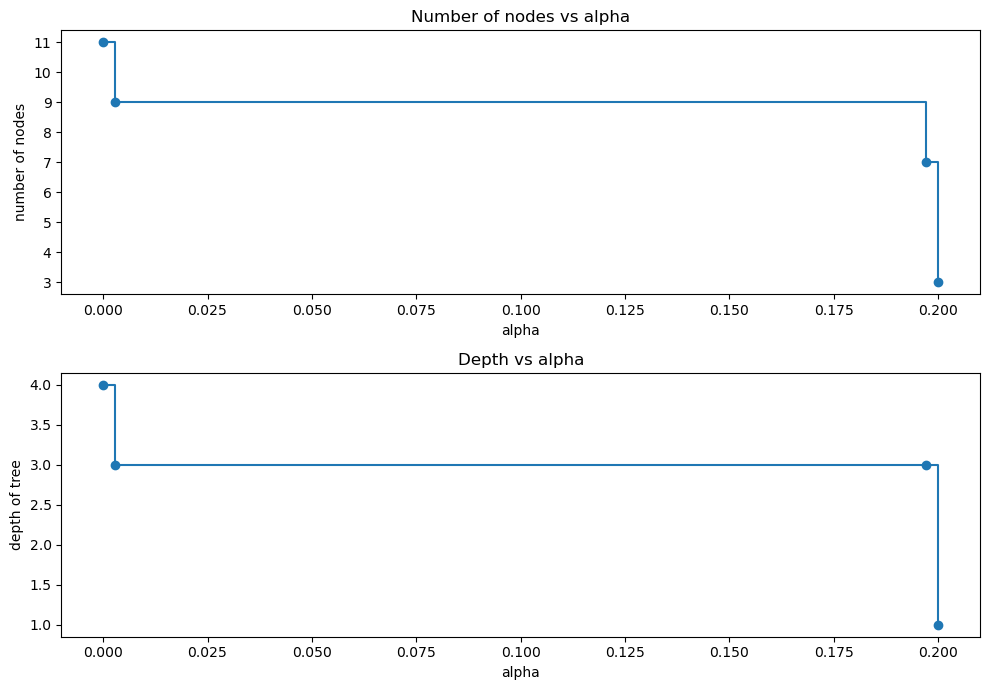

In [88]:
# Drop the last alpha: it always collapses the tree to a single root node
# (uninformative) - see the last line printed in the loop above (leaves=1).
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

### Recall vs α (Train/Test): Pick α giving the best generalization

In [89]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train, average='weighted')
    recall_train.append(values_train)

In [90]:
recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test, average='weighted')
    recall_test.append(values_test)

In [91]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

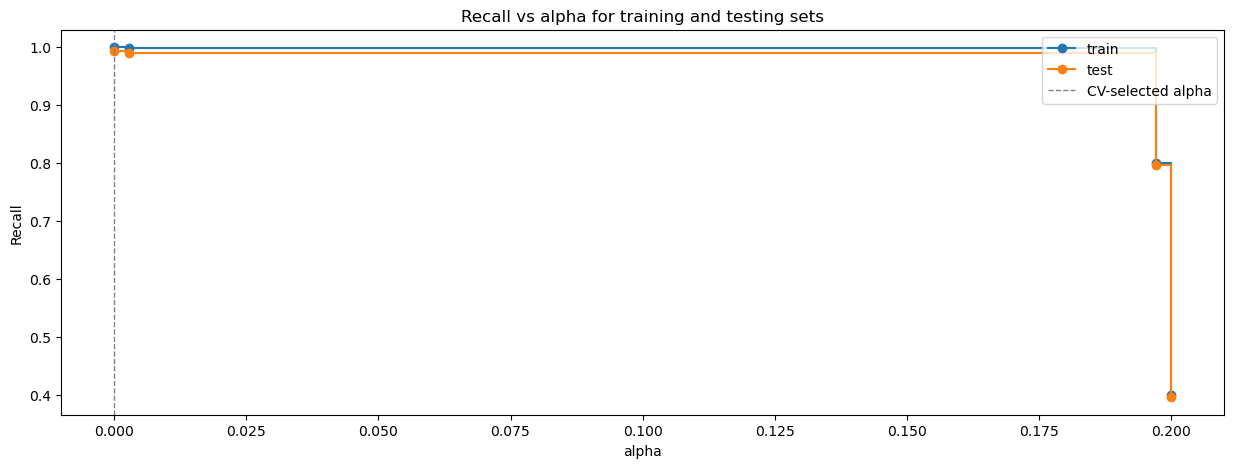

In [92]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(
    ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post",
)
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.axvline(model2.ccp_alpha, color="gray", linestyle="--", linewidth=1, label="CV-selected alpha")
ax.legend()
plt.show()

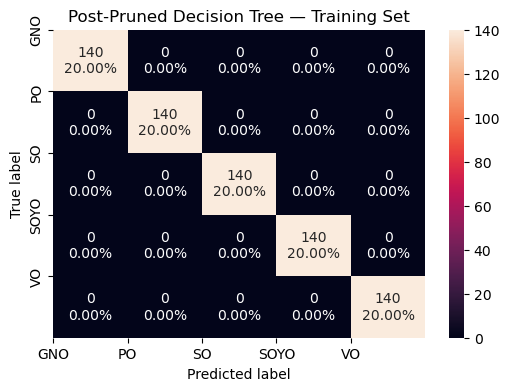

In [94]:
model3 = model2
confusion_matrix_sklearn(model3, X_train, y_train)
ax = plt.gca()
labels = ['GNO', 'PO', 'SO', 'SOYO', 'VO']
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_title("Post-Pruned Decision Tree — Training Set")
plt.savefig(r"C:\Users\Admin\Downloads\Decision tree_oil_peak normalized data\confusion_matrix_train_postpruned_oil.jpg",dpi=300,bbox_inches="tight")
plt.show()

In [95]:
decision_tree_post_perf_train = model_performance_classification_sklearn(
    model3, X_train, y_train
)
decision_tree_post_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


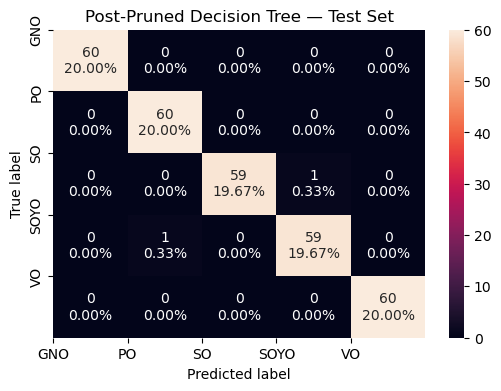

In [97]:
confusion_matrix_sklearn(model3, X_test, y_test)
ax = plt.gca()
labels = ['GNO', 'PO', 'SO', 'SOYO', 'VO']
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_title("Post-Pruned Decision Tree — Test Set")
plt.savefig(r"C:\Users\Admin\Downloads\Decision tree_oil_peak normalized data\confusion_matrix_test_postpruned_oil.jpg",dpi=300,bbox_inches="tight")
plt.show()

In [98]:
decision_tree_post_test = model_performance_classification_sklearn(
    model3, X_test, y_test
)
decision_tree_post_test

,Accuracy,Recall,Precision,F1
0,0.993333,0.993333,0.993388,0.993333


### decision tree for post-pruning

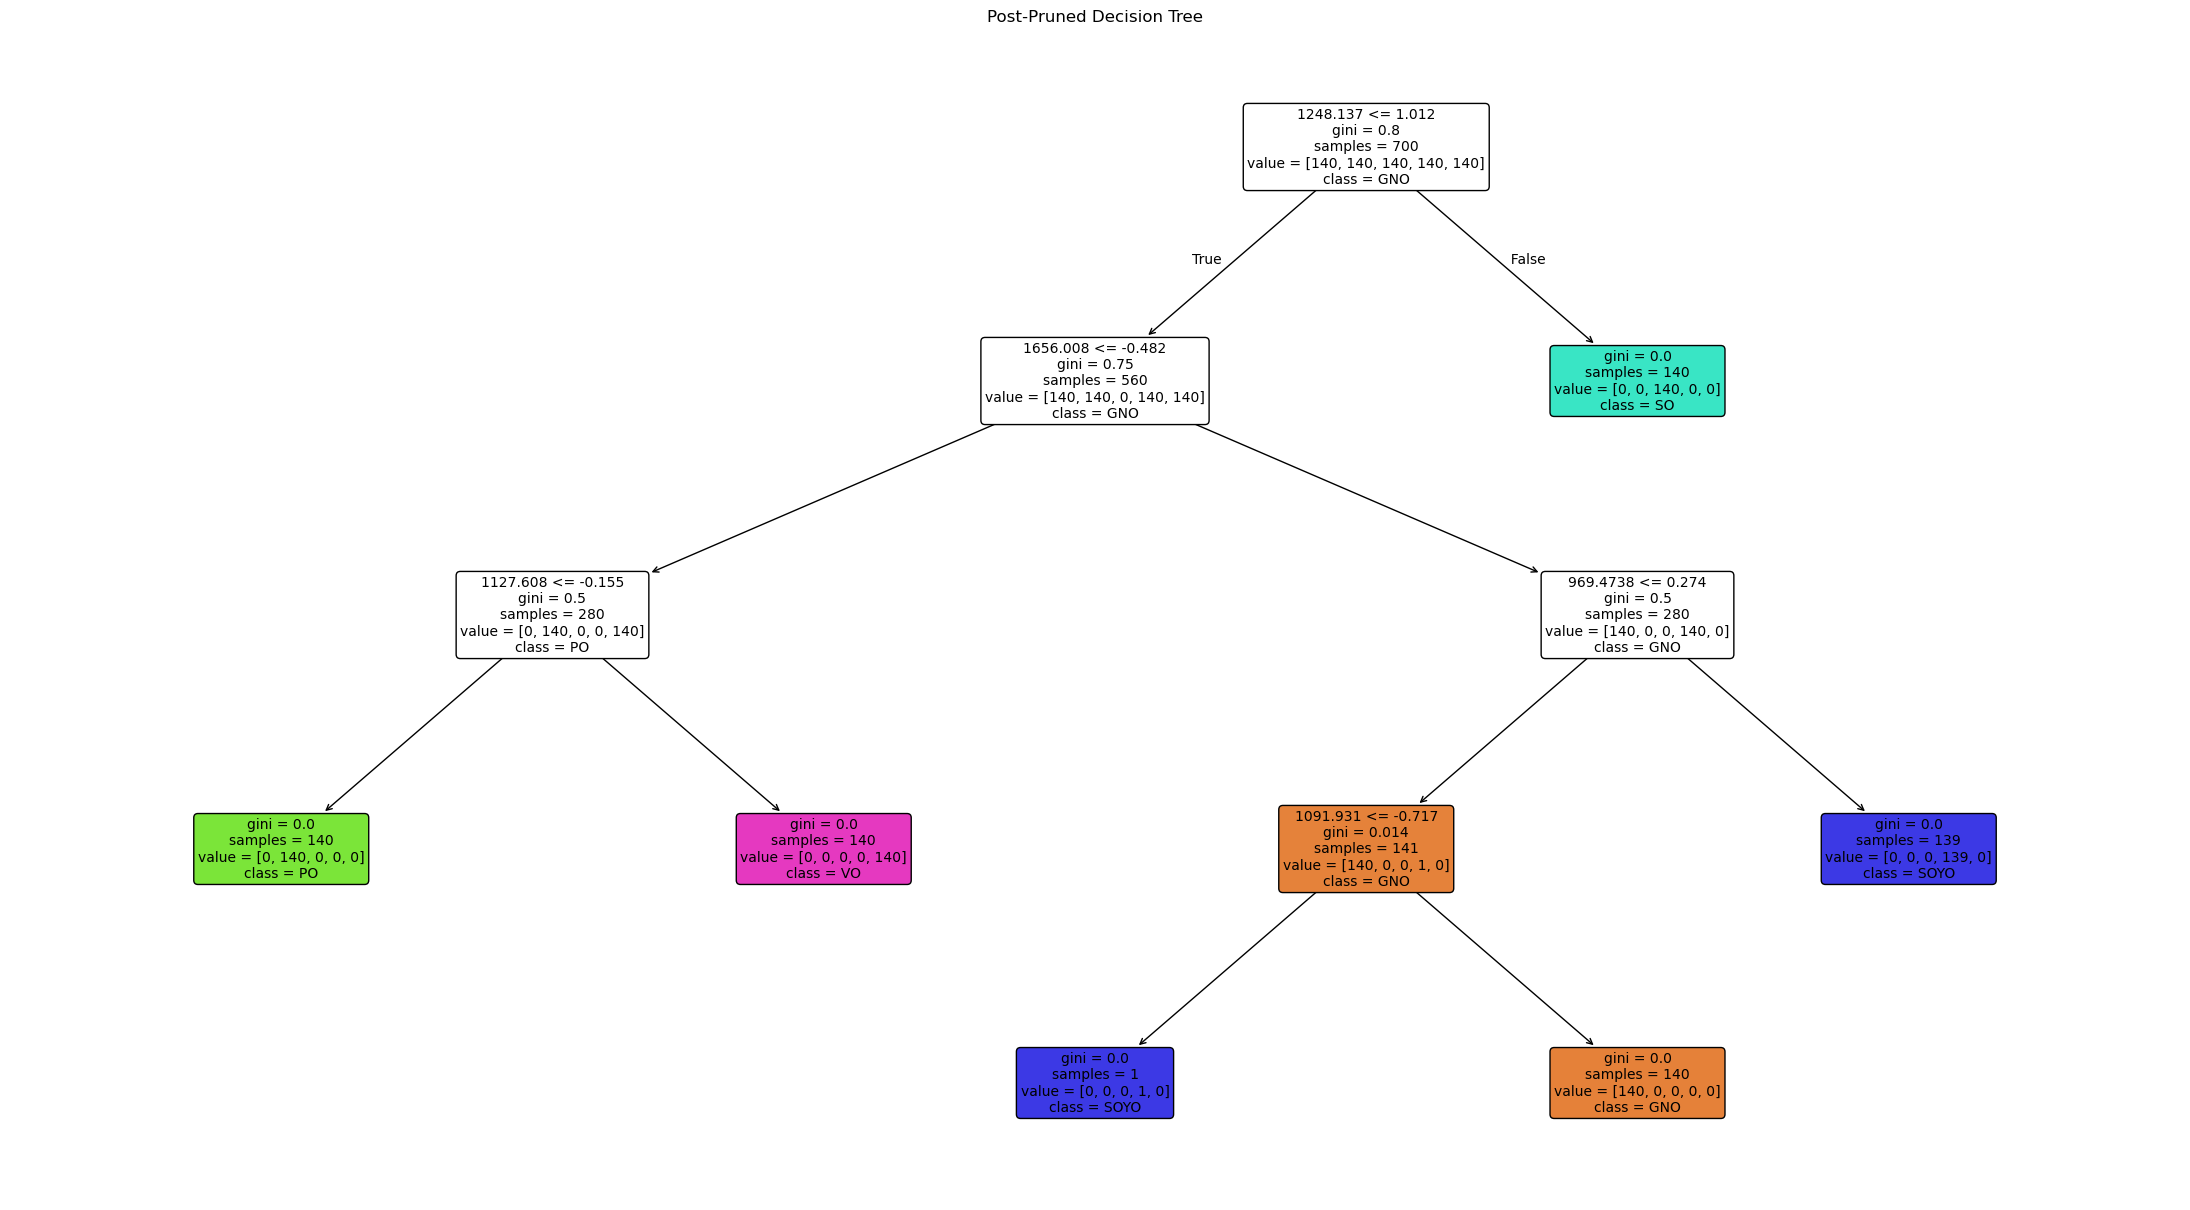

In [99]:
class_names = ['GNO', 'PO', 'SO', 'SOYO', 'VO']
plt.figure(figsize=(22, 12))

out = tree.plot_tree(
    model3,
    feature_names=feature_names,
    class_names=class_names,   # <-- add class labels
    filled=True,
    rounded=True,
    fontsize=10,
    node_ids=False,
    proportion=False,          # keep sample counts
    impurity=True              # keep gini values
)

# Make arrows darker
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)

plt.tight_layout()

plt.title("Post-Pruned Decision Tree")
plt.savefig(r"C:\Users\Admin\Downloads\Decision tree_oil_peak normalized data\postpruned_decision_tree_oils.jpg",dpi=600,bbox_inches="tight")
plt.show()

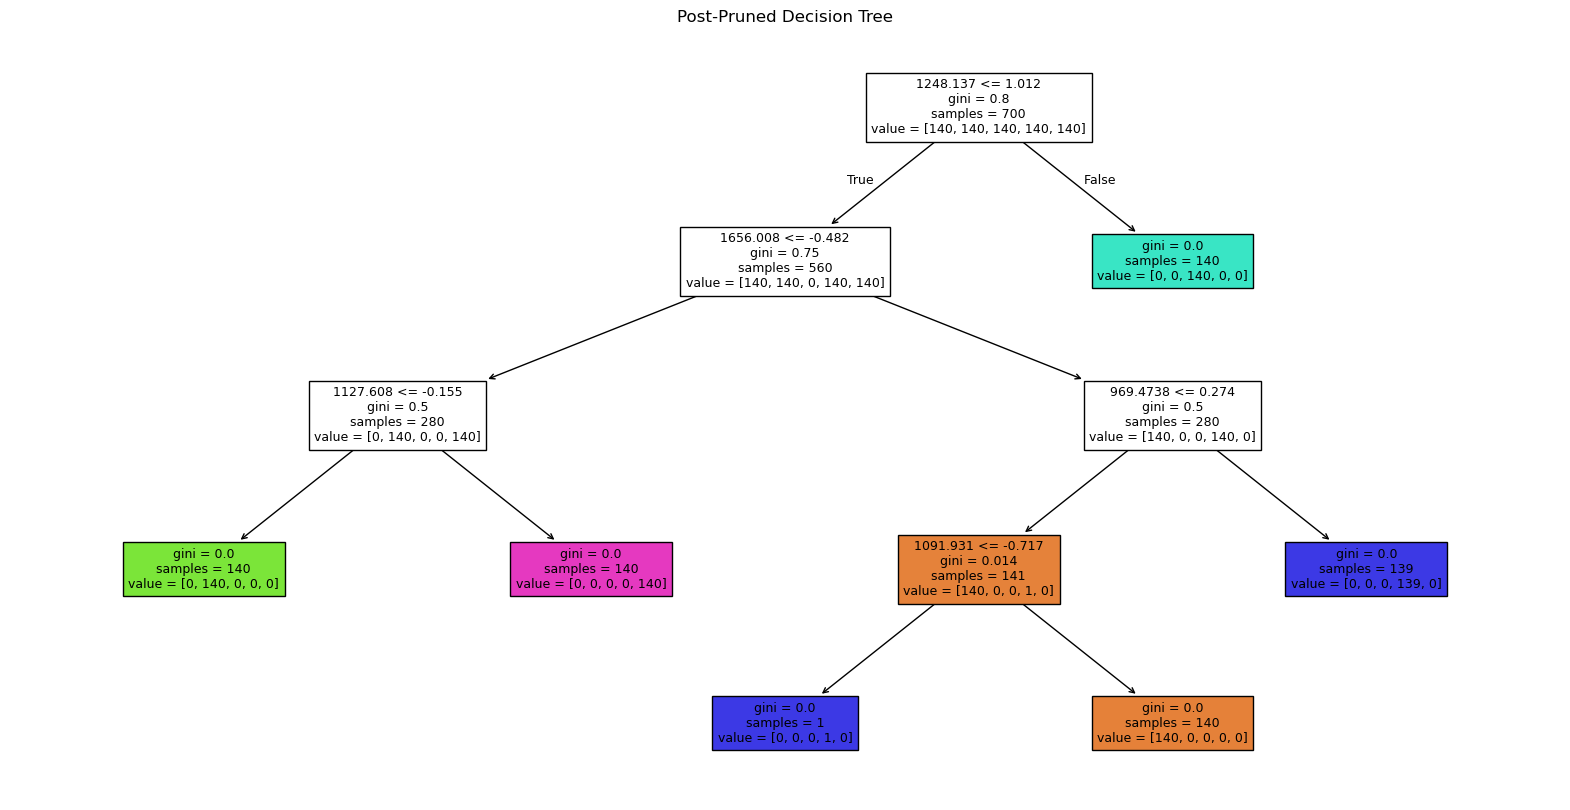

In [100]:
plt.figure(figsize=(20, 10))

out = tree.plot_tree(
    model3,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.title("Post-Pruned Decision Tree")
plt.show()

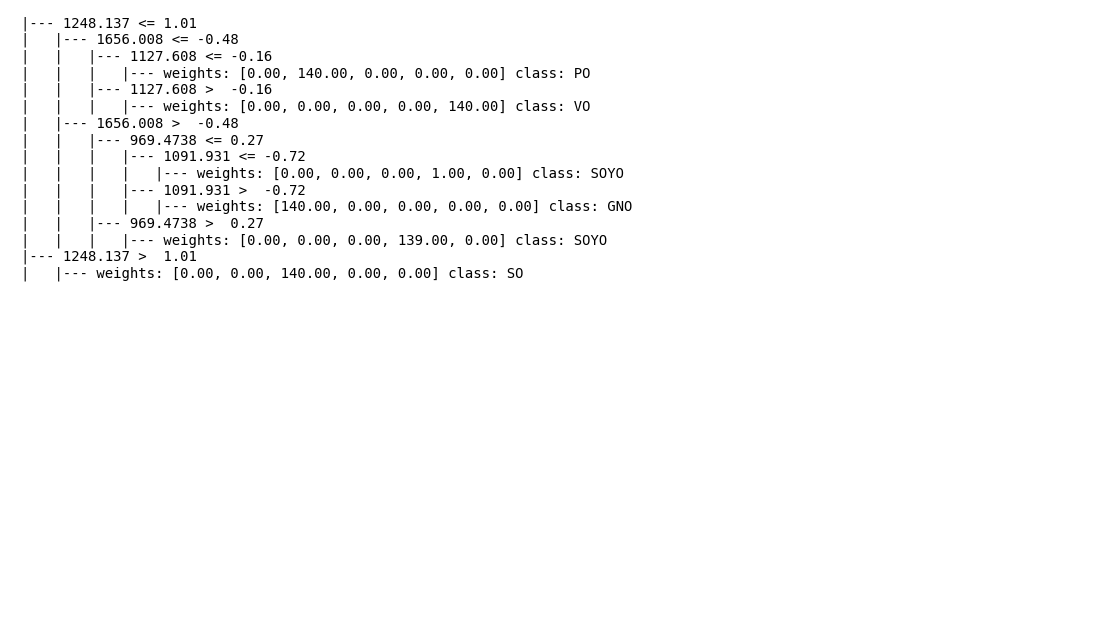

In [101]:
report = tree.export_text(
    model3,
    feature_names=feature_names,
    show_weights=True
)

fig, ax = plt.subplots(figsize=(14, 8))
ax.axis("off")

ax.text(
    0.01,
    0.99,
    report,
    transform=ax.transAxes,
    fontsize=10,
    family="monospace",
    va="top"
)

plt.savefig(r"C:\Users\Admin\Downloads\Decision tree_oil_peak normalized data\postpruned_tree_rules_oils.jpg",dpi=600,bbox_inches="tight")
plt.show()

In [102]:
# Text report showing the rules of a decision tree -
print(tree.export_text(model3, feature_names=feature_names, show_weights=True))

|--- 1248.137 <= 1.01
|   |--- 1656.008 <= -0.48
|   |   |--- 1127.608 <= -0.16
|   |   |   |--- weights: [0.00, 140.00, 0.00, 0.00, 0.00] class: PO
|   |   |--- 1127.608 >  -0.16
|   |   |   |--- weights: [0.00, 0.00, 0.00, 0.00, 140.00] class: VO
|   |--- 1656.008 >  -0.48
|   |   |--- 969.4738 <= 0.27
|   |   |   |--- 1091.931 <= -0.72
|   |   |   |   |--- weights: [0.00, 0.00, 0.00, 1.00, 0.00] class: SOYO
|   |   |   |--- 1091.931 >  -0.72
|   |   |   |   |--- weights: [140.00, 0.00, 0.00, 0.00, 0.00] class: GNO
|   |   |--- 969.4738 >  0.27
|   |   |   |--- weights: [0.00, 0.00, 0.00, 139.00, 0.00] class: SOYO
|--- 1248.137 >  1.01
|   |--- weights: [0.00, 0.00, 140.00, 0.00, 0.00] class: SO



In [103]:
importances = model3.feature_importances_
indices = np.argsort(importances)

In [104]:
np.sum(importances > 0)

np.int64(5)

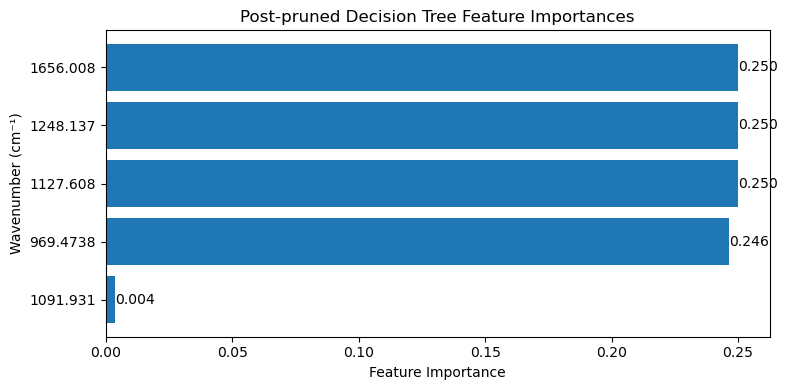

In [105]:
importances = model3.feature_importances_

# Keep only important features
mask = importances > 0

important_features = np.array(feature_names)[mask]
important_importances = importances[mask]

# Sort
idx = np.argsort(important_importances)

plt.figure(figsize=(8,4))

plt.barh(
    important_features[idx],
    important_importances[idx]
)

plt.xlabel("Feature Importance")
plt.ylabel("Wavenumber (cm⁻¹)")
plt.title("Post-pruned Decision Tree Feature Importances")

# Print values on bars
for i, v in enumerate(important_importances[idx]):
    plt.text(v, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.savefig(r"C:\Users\Admin\Downloads\Decision tree_oil_peak normalized data\PostPruned_Feature_Importance_oils.jpg",dpi=600,bbox_inches="tight")
plt.show()

In [106]:
imp_df = pd.DataFrame({
    "Wavenumber": np.array(feature_names)[mask],
    "Importance": importances[mask]
})

imp_df = imp_df.sort_values(
    "Importance",
    ascending=False
)

print(imp_df)

  Wavenumber  Importance
2   1127.608    0.250000
3   1248.137    0.250000
4   1656.008    0.250000
0   969.4738    0.246454
1   1091.931    0.003546


### Comparision

In [107]:
# training performance comparison
models_train_comp_df = pd.concat(
    [
        decision_tree_default_perf_train.T,
        decision_tree_tune_perf_train.T,
        decision_tree_post_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.0,1.0,1.0
Recall,1.0,1.0,1.0
Precision,1.0,1.0,1.0
F1,1.0,1.0,1.0


In [108]:
# testing performance comparison
models_test_comp_df = pd.concat(
    [
        decision_tree_default_perf_test.T,
        decision_tree_tune_perf_test.T,
        decision_tree_post_test.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.993333,0.993333,0.993333
Recall,0.993333,0.993333,0.993333
Precision,0.993388,0.993388,0.993388
F1,0.993333,0.993333,0.993333


In [109]:
hyperparameter_comparison = pd.DataFrame({
    "Default Tree": model0.get_params(deep=True),
    "Pre-Pruned Tree": model1.get_params(deep=True),
    "Post-Pruned Tree": model2.get_params(deep=True)
})

print(hyperparameter_comparison)

                         Default Tree Pre-Pruned Tree Post-Pruned Tree
ccp_alpha                         0.0             0.0              0.0
class_weight                 balanced        balanced         balanced
criterion                        gini            gini             gini
max_depth                        None               4             None
max_features                     None            None             None
max_leaf_nodes                   None              50             None
min_impurity_decrease             0.0             0.0              0.0
min_samples_leaf                    1               1                1
min_samples_split                   2              10                2
min_weight_fraction_leaf          0.0             0.0              0.0
monotonic_cst                    None            None             None
random_state                        1               1                1
splitter                         best            best             best


##### "None" generally means that no explicit numerical restriction/alternative value was specified for that hyperparameter. The exact interpretation depends on the parameter.max_depth = None implies that the maximum depth of the tree was not explicitly limited.The tree can continue splitting until other stopping conditions are met.

In [110]:
def plot_topk_importances(estimator, feature_names, top_k=20, title="Top feature importances"):
    importances = getattr(estimator, 'feature_importances_', None)
    if importances is None:
        raise ValueError("Estimator has no attribute 'feature_importances_'.")

    imp = pd.Series(importances, index=feature_names)
    imp_nz = imp[imp > 0].sort_values(ascending=False)
    if imp_nz.empty:
        print('All importances are zero (common for some pruned trees).')
        return

    top = imp_nz.head(top_k).sort_values()   # ascending for barh
    plt.figure(figsize=(8, max(3, 0.4*len(top))))
    plt.title(f"{title} (top {len(top)})")
    plt.barh(top.index, top.values, color='mediumpurple')
    plt.xlabel('Gini importance (relative)')
    plt.ylabel('Wavenumber (cm⁻¹)')
    plt.tight_layout()
    plt.show()

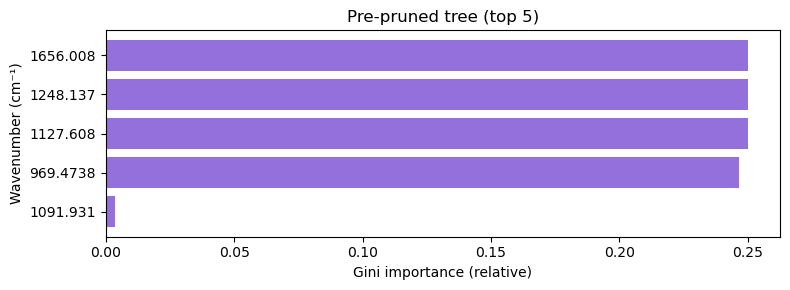

In [111]:
plot_topk_importances(model2, feature_names, top_k=25, title='Pre‑pruned tree')

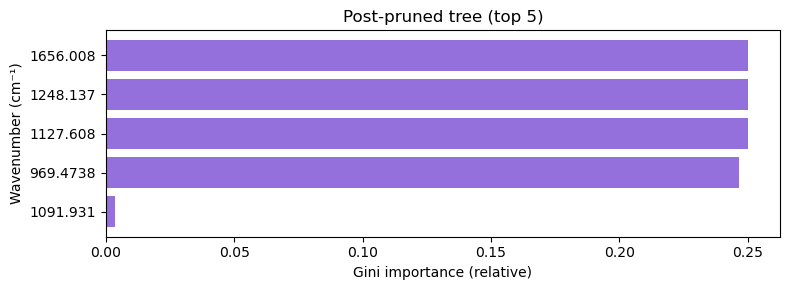

In [112]:
plot_topk_importances(model3, feature_names, top_k=25, title='Post‑pruned tree')